# 01. Clustering Algorithms: Comparative Analysis and Implementation
**Algorithms Covered:**
1. **K-Means Clustering** (Standard Lloyd's Algorithm)
2. **Modified K-Means** (Bisecting K-Means & K-Means++ Initialization)
3. **Hierarchical Clustering** (Agglomerative Clustering with Dendrogram Visualization)
4. **Fuzzy C-Means (FCM)** (Soft Clustering with Membership Degrees)

**Dataset:** Real-World Mall Customers Dataset (`data/mall_customers.csv`) and Synthetic Benchmark Multi-Cluster Data.


In [1]:
# ---- Core numerical and plotting libraries ----
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Scikit-Learn clustering models ----
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering
# ---- Feature scaling + unsupervised evaluation metrics ----
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# ---- SciPy hierarchical clustering utilities (linkage + dendrogram) ----
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

# Fix the random seed so every run reproduces the same results
np.random.seed(42)
print("Libraries successfully imported!")


Libraries successfully imported!


## 1. Data Loading and Exploratory Data Analysis (EDA)
We load the **Mall Customers** dataset, which consists of customer demographics, annual income (in $k), and spending score (1-100).


In [2]:
# ---- Load the Mall Customers dataset (path is relative to the notebooks/ folder) ----
df_mall = pd.read_csv('../data/mall_customers.csv')

# Inspect the shape (rows, columns) and preview the first five rows
print("Dataset Shape:", df_mall.shape)
df_mall.head()


Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# ---- Data quality check: count missing values per column ----
print("Missing values per column:\n", df_mall.isnull().sum())

# ---- Descriptive statistics (mean, std, min, quartiles, max) for numeric columns ----
df_mall.describe()


Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


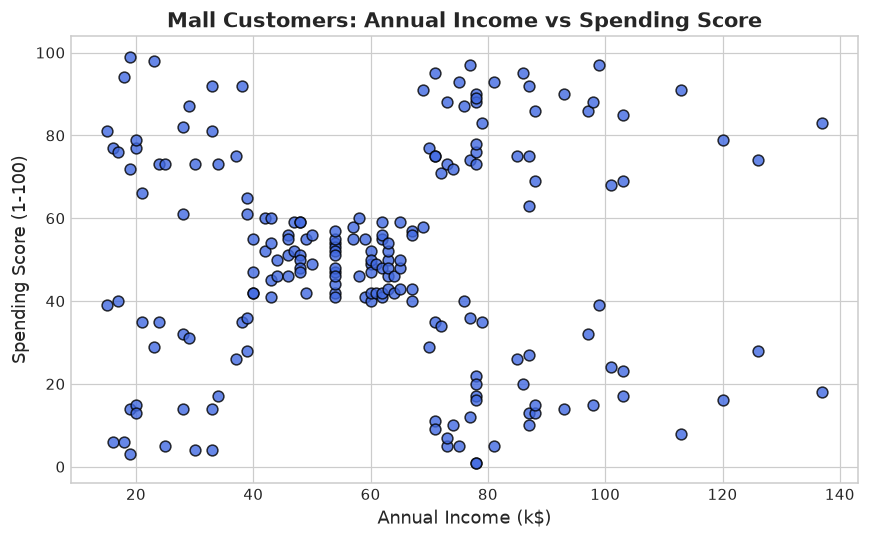

In [4]:
# ---- Feature selection and normalization ----
# We cluster on two informative dimensions so the result can be visualized in 2D:
# Annual Income and Spending Score.
feature_cols = ['Annual_Income_k$', 'Spending_Score'] if 'Annual_Income_k$' in df_mall.columns else ['Annual Income (k$)', 'Spending Score (1-100)']
X_mall = df_mall[feature_cols].values

# Standardize features (mean = 0, std = 1) so both dimensions contribute equally
# to Euclidean distance - distance-based algorithms are scale-sensitive.
scaler = StandardScaler()
X_mall_scaled = scaler.fit_transform(X_mall)

# Scatter plot of the raw (unscaled) data to inspect its structure before clustering
plt.figure(figsize=(8, 5))
plt.scatter(X_mall[:, 0], X_mall[:, 1], c='royalblue', edgecolors='k', s=50, alpha=0.8)
plt.title("Mall Customers: Annual Income vs Spending Score", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Algorithm 1: Standard K-Means Clustering
### Mathematical Formulation
Given dataset $X = \{x_1, x_2, \dots, x_n\}$, K-Means partitions the data into $K$ disjoint clusters $C_1, C_2, \dots, C_K$ by minimizing the Within-Cluster Sum of Squares (WCSS / Inertia):
$$J = \sum_{k=1}^K \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$
where $\mu_k = \frac{1}{|C_k|}\sum_{x_i \in C_k} x_i$ is the centroid of cluster $C_k$.

### Determining Optimal $K$: Elbow Method & Silhouette Analysis


### Step-by-Step Algorithm (Lloyd's K-Means)
1. **Choose K** and initialize K centroids (here with K-Means++ for a strong start).
2. **Assignment step:** assign every sample to the nearest centroid (Euclidean distance).
3. **Update step:** move each centroid to the mean of the samples assigned to it.
4. **Repeat** steps 2-3 until assignments/centroids stop changing or the iteration limit is reached.
5. **Output:** final centroids, hard cluster labels, and the inertia (WCSS) used for model selection.

### How K Is Selected in This Notebook
1. Fit K-Means for K = 2...10.
2. Record inertia (elbow curve) and silhouette score for each K.
3. Pick the K at the "elbow" / highest silhouette (K = 5 here) and refit the final model.


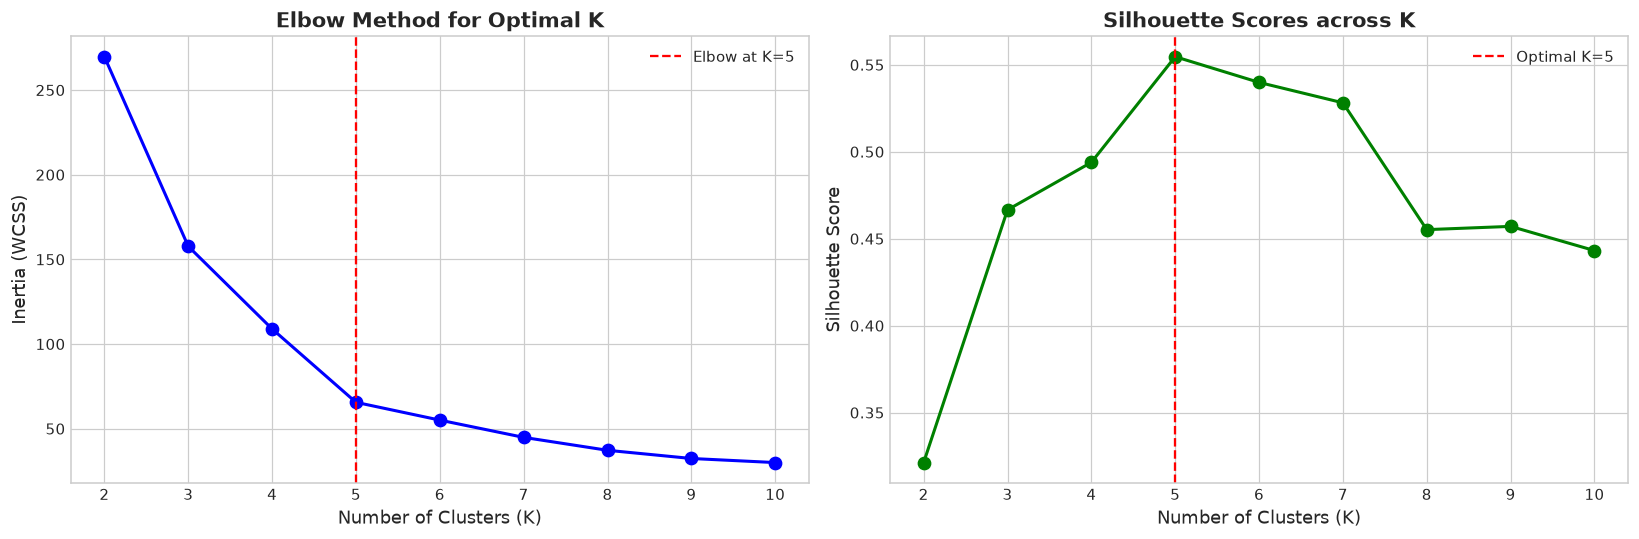

In [5]:
# ---- Selecting the optimal number of clusters K ----
# Try K = 2..10 and record two diagnostics:
#   * Inertia (WCSS): total squared distance from points to their centroid
#   * Silhouette score: cluster cohesion vs. separation
k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    # n_init=10 runs K-Means from 10 different seeds and keeps the best run
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_mall_scaled)
    wcss.append(kmeans.inertia_)                                               # WCSS of the fitted model
    silhouette_scores.append(silhouette_score(X_mall_scaled, kmeans.labels_))  # partition quality

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ---- Left: elbow curve (look for the "knee" where inertia stops falling quickly) ----
ax1.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("Inertia (WCSS)", fontsize=12)
ax1.axvline(x=5, color='r', linestyle='--', label='Elbow at K=5')
ax1.legend()

# ---- Right: silhouette score for each K (higher is better) ----
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title("Silhouette Scores across K", fontsize=14, fontweight='bold')
ax2.set_xlabel("Number of Clusters (K)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.axvline(x=5, color='r', linestyle='--', label='Optimal K=5')
ax2.legend()

plt.tight_layout()
plt.show()


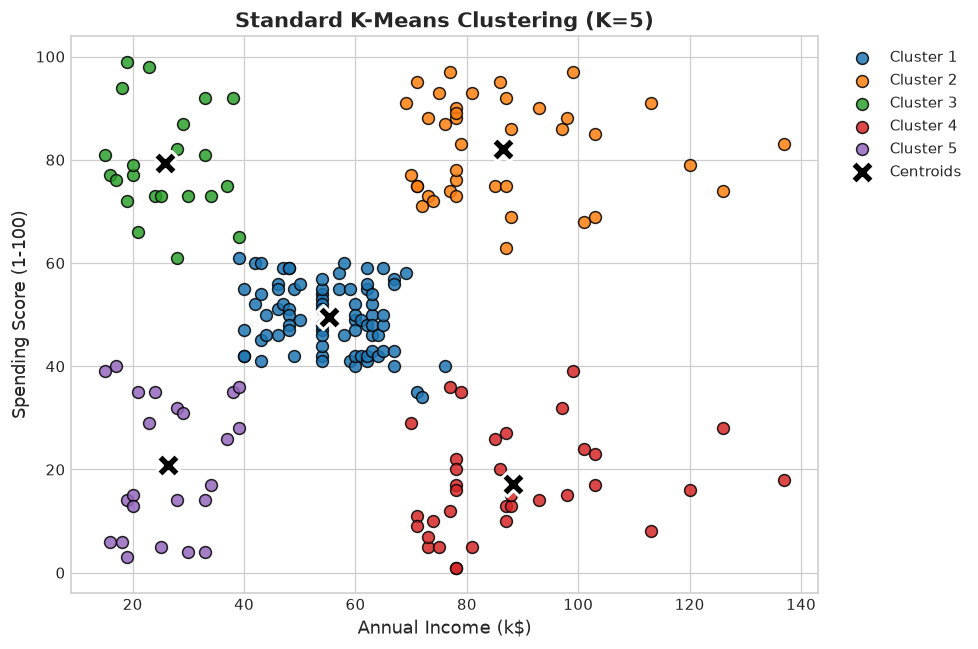

K-Means Silhouette Score: 0.5547
K-Means Davies-Bouldin Index: 0.5722


In [6]:
# ---- Final K-Means model with the selected K = 5 ----
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_mall_scaled)                   # hard cluster assignment per sample
kmeans_centers = scaler.inverse_transform(kmeans_model.cluster_centers_)  # convert centroids back to original units

# ---- Visualize the clusters and centroids in the original feature space ----
plt.figure(figsize=(9, 6))
palette = sns.color_palette("deep", optimal_k)
for cluster_id in range(optimal_k):
    cluster_points = X_mall[kmeans_labels == cluster_id]  # points belonging to this cluster
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id + 1}', s=60, edgecolors='k', alpha=0.85)

plt.scatter(kmeans_centers[:, 0], kmeans_centers[:, 1], c='black', marker='X', s=250, label='Centroids', edgecolors='white', linewidths=2)
plt.title("Standard K-Means Clustering (K=5)", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Quantitative evaluation (computed on the standardized features) ----
print(f"K-Means Silhouette Score: {silhouette_score(X_mall_scaled, kmeans_labels):.4f}")
print(f"K-Means Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, kmeans_labels):.4f}")


## 3. Algorithm 2: Modified K-Means
Modified variants of K-Means address known limitations of the standard algorithm:
1. **K-Means++ Initialization**: Selects initial cluster centers with probability proportional to the squared Euclidean distance to the nearest existing center, drastically reducing convergence time and sensitivity to local minima.
2. **Bisecting K-Means**: A hierarchical divisive variant that repeatedly splits clusters using 2-means until $K$ clusters are obtained. It produces more uniform and consistent cluster sizes.


### Step-by-Step Algorithm (Modified K-Means Variants)
**A. K-Means++ initialization**
1. Pick the first centroid uniformly at random from the data.
2. For every point compute D(x)^2 = squared distance to the nearest chosen centroid.
3. Pick the next centroid randomly with probability proportional to D(x)^2.
4. Repeat steps 2-3 until K centroids are chosen, then run standard K-Means.
*Benefit:* avoids poor random starts, converges faster and more consistently.

**B. Bisecting K-Means (divisive)**
1. Start with all samples in a single cluster.
2. Select the cluster with the largest inertia (or largest size).
3. Split it into two using 2-means (try multiple restarts, keep the split with the lowest SSE).
4. Repeat steps 2-3 until exactly K clusters are obtained.
*Benefit:* more balanced, stable cluster sizes and less sensitivity to initialization.


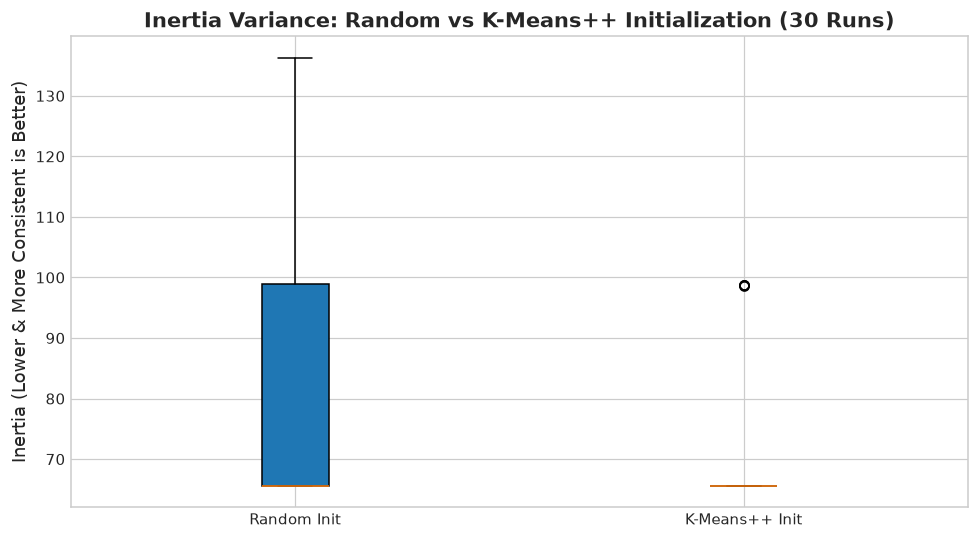

Random Init Mean Inertia: 83.44 (std: 22.08)
K-Means++ Mean Inertia:  69.99 (std: 11.26)


In [7]:
# ---- Experiment: K-Means++ vs random initialization stability ----
# Run both initializations 30 times (one seed each) and compare the resulting inertia.
# A stable initialization should produce consistently low inertia across seeds.
n_trials = 30
inertia_random = []
inertia_kpp = []

for seed in range(n_trials):
    # (a) Plain random centroid initialization
    km_rnd = KMeans(n_clusters=5, init='random', n_init=1, random_state=seed)
    km_rnd.fit(X_mall_scaled)
    inertia_random.append(km_rnd.inertia_)

    # (b) K-Means++ smart initialization (spreads initial centroids apart)
    km_kpp = KMeans(n_clusters=5, init='k-means++', n_init=1, random_state=seed)
    km_kpp.fit(X_mall_scaled)
    inertia_kpp.append(km_kpp.inertia_)

# Boxplot compares the spread (variance) of the two strategies
plt.figure(figsize=(9, 5))
plt.boxplot([inertia_random, inertia_kpp], tick_labels=['Random Init', 'K-Means++ Init'], patch_artist=True)
plt.title("Inertia Variance: Random vs K-Means++ Initialization (30 Runs)", fontsize=14, fontweight='bold')
plt.ylabel("Inertia (Lower & More Consistent is Better)", fontsize=12)
plt.tight_layout()
plt.show()

# Mean and standard deviation summarize stability (lower std = more reliable)
print(f"Random Init Mean Inertia: {np.mean(inertia_random):.2f} (std: {np.std(inertia_random):.2f})")
print(f"K-Means++ Mean Inertia:  {np.mean(inertia_kpp):.2f} (std: {np.std(inertia_kpp):.2f})")


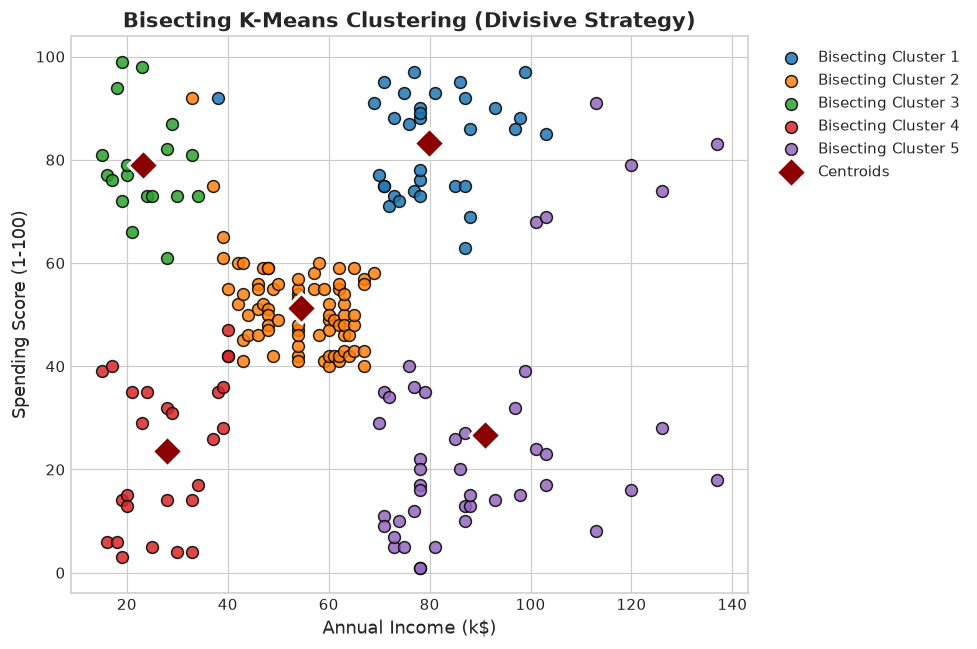

Bisecting K-Means Silhouette Score: 0.4807
Bisecting K-Means Davies-Bouldin Index: 0.6788


In [8]:
# ---- Bisecting K-Means (divisive variant of K-Means) ----
# Repeatedly splits the cluster with the biggest inertia using 2-means until K clusters remain.
bisecting_km = BisectingKMeans(n_clusters=optimal_k, random_state=42, bisecting_strategy='biggest_inertia')
bisecting_labels = bisecting_km.fit_predict(X_mall_scaled)
bisecting_centers = scaler.inverse_transform(bisecting_km.cluster_centers_)

# ---- Visualize the partition produced by the divisive strategy ----
plt.figure(figsize=(9, 6))
for cluster_id in range(optimal_k):
    cluster_points = X_mall[bisecting_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Bisecting Cluster {cluster_id + 1}', s=60, edgecolors='k', alpha=0.85)

plt.scatter(bisecting_centers[:, 0], bisecting_centers[:, 1], c='darkred', marker='D', s=200, label='Centroids', edgecolors='white', linewidths=2)
plt.title("Bisecting K-Means Clustering (Divisive Strategy)", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Evaluation of the bisecting partition ----
print(f"Bisecting K-Means Silhouette Score: {silhouette_score(X_mall_scaled, bisecting_labels):.4f}")
print(f"Bisecting K-Means Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, bisecting_labels):.4f}")


## 4. Algorithm 3: Hierarchical Clustering (Agglomerative)
### Mathematical Formulation
Agglomerative clustering begins with each point as its own cluster and iteratively merges the closest pair of clusters until only one cluster remains.
Using **Ward's Linkage**, the distance between cluster $A$ and cluster $B$ measures the increase in total within-cluster variance upon merging:
$$\Delta W(A, B) = \frac{n_A n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$


### Step-by-Step Algorithm (Agglomerative / Ward)
1. Start with N singleton clusters (one per sample).
2. Compute pairwise distances between all clusters using Ward's criterion: ΔW(A,B) = (n_A n_B)/(n_A+n_B) · ||μ_A − μ_B||².
3. Merge the two clusters with the smallest ΔW (least increase in within-cluster variance).
4. Update distances between the new cluster and all remaining clusters.
5. Repeat steps 3-4 until a single cluster remains.
6. Cut the dendrogram at the chosen height (or choose K) to obtain the final partition.


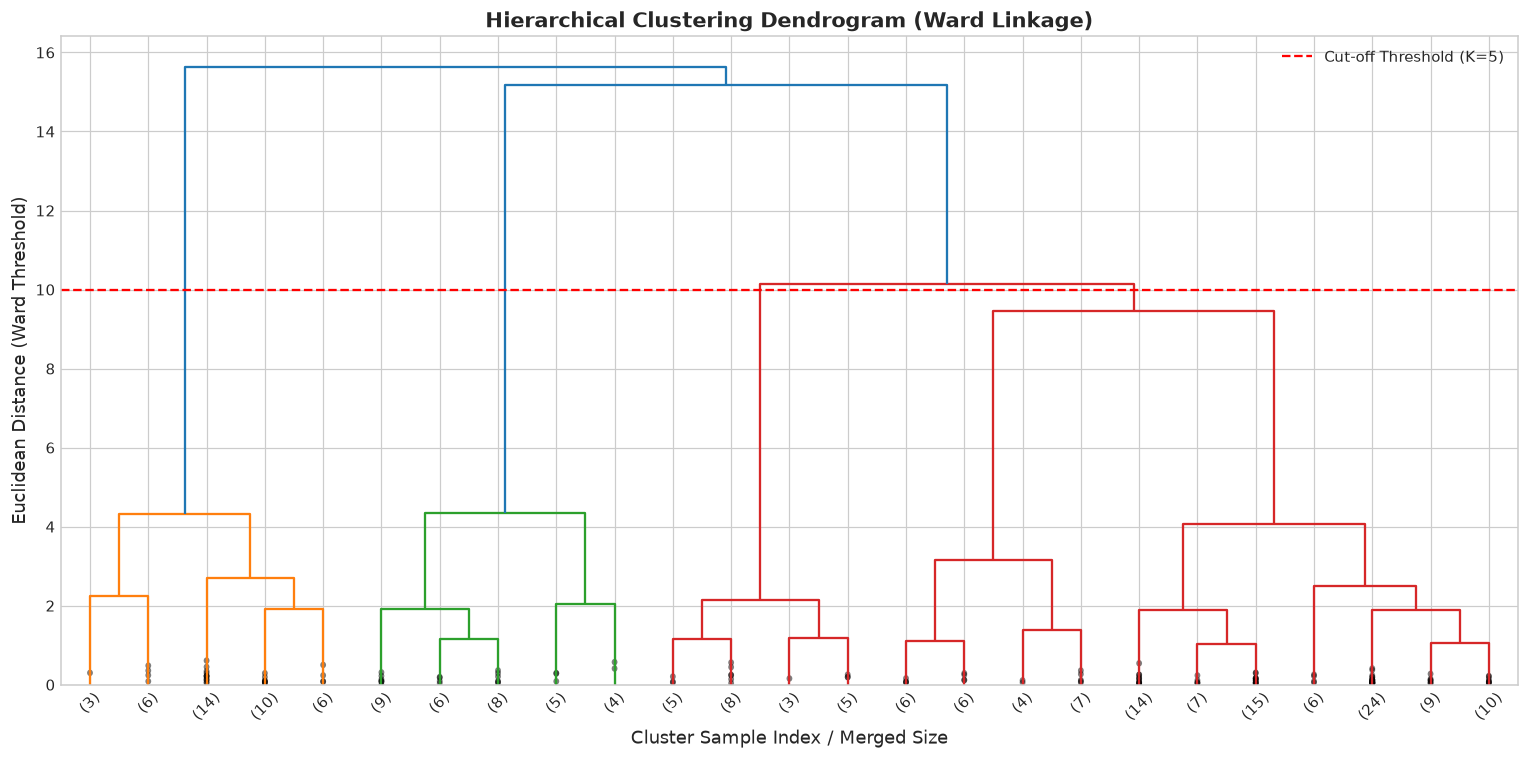

In [9]:
# ---- Build the linkage matrix and draw the dendrogram ----
# 'ward' linkage merges the pair of clusters that increases within-cluster variance the least.
linkage_matrix = linkage(X_mall_scaled, method='ward')

# The dendrogram shows every merge; we truncate it to the last 25 merges for readability.
plt.figure(figsize=(14, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',   # show only the last p merged clusters
    p=25,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True     # condensed leaves are shown as counts
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Sample Index / Merged Size", fontsize=12)
plt.ylabel("Euclidean Distance (Ward Threshold)", fontsize=12)
plt.axhline(y=10.0, color='r', linestyle='--', label='Cut-off Threshold (K=5)')  # horizontal cut => cluster count
plt.legend()
plt.tight_layout()
plt.show()


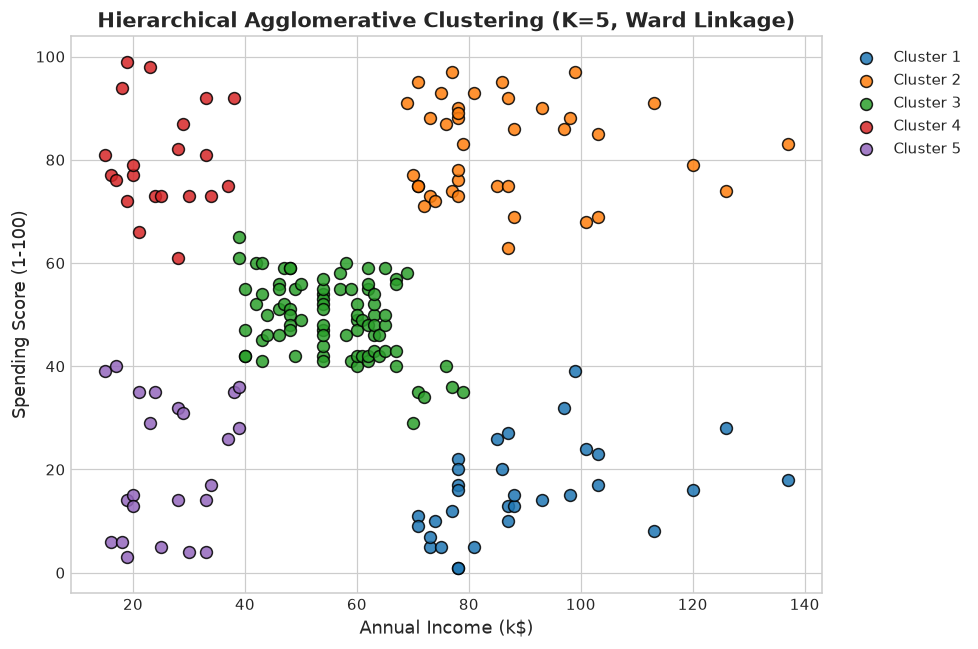

Hierarchical Silhouette Score: 0.5538
Hierarchical Davies-Bouldin Index: 0.5779


In [10]:
# ---- Fit the final Agglomerative (bottom-up hierarchical) model with K = 5 ----
# metric='euclidean' + linkage='ward' implements Ward's minimum-variance criterion.
agg_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
agg_labels = agg_model.fit_predict(X_mall_scaled)

# ---- Visualize the hierarchical partition ----
plt.figure(figsize=(9, 6))
for cluster_id in range(optimal_k):
    cluster_points = X_mall[agg_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id + 1}', s=60, edgecolors='k', alpha=0.85)

plt.title("Hierarchical Agglomerative Clustering (K=5, Ward Linkage)", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Evaluation of the hierarchical partition ----
print(f"Hierarchical Silhouette Score: {silhouette_score(X_mall_scaled, agg_labels):.4f}")
print(f"Hierarchical Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, agg_labels):.4f}")


## 5. Algorithm 4: Fuzzy C-Means (FCM)
### Mathematical Formulation
Unlike hard clustering (K-Means), Fuzzy C-Means assigns each sample $x_i$ a **fuzzy membership degree** $u_{ik} \in [0, 1]$ across all $K$ clusters such that $\sum_{k=1}^K u_{ik} = 1$.
The objective function is:
$$J_m = \sum_{i=1}^N \sum_{k=1}^K u_{ik}^m \|x_i - v_k\|^2, \quad m > 1$$
Where:
- $m$ is the fuzzifier (typically $m=2.0$).
- Centroid update: $v_k = \frac{\sum_{i=1}^N u_{ik}^m x_i}{\sum_{i=1}^N u_{ik}^m}$
- Membership update: $u_{ik} = \frac{1}{\sum_{j=1}^K \left(\frac{\|x_i - v_k\|}{\|x_i - v_j\|}\right)^{\frac{2}{m-1}}}$


### Step-by-Step Algorithm (Fuzzy C-Means)
1. Choose K, fuzzifier m > 1 and tolerance ε; initialize the membership matrix U randomly so each row sums to 1.
2. **Centroid update:** v_k = Σ_i u_ik^m x_i / Σ_i u_ik^m.
3. **Membership update:** u_ik = 1 / Σ_j (||x_i − v_k|| / ||x_i − v_j||)^(2/(m−1)).
4. **Repeat** steps 2-3 until max |U_new − U_old| < ε or the iteration limit is reached.
5. **Output:** fuzzy memberships u_ik (soft assignment) and centroids; hard labels come from argmax_k u_ik.


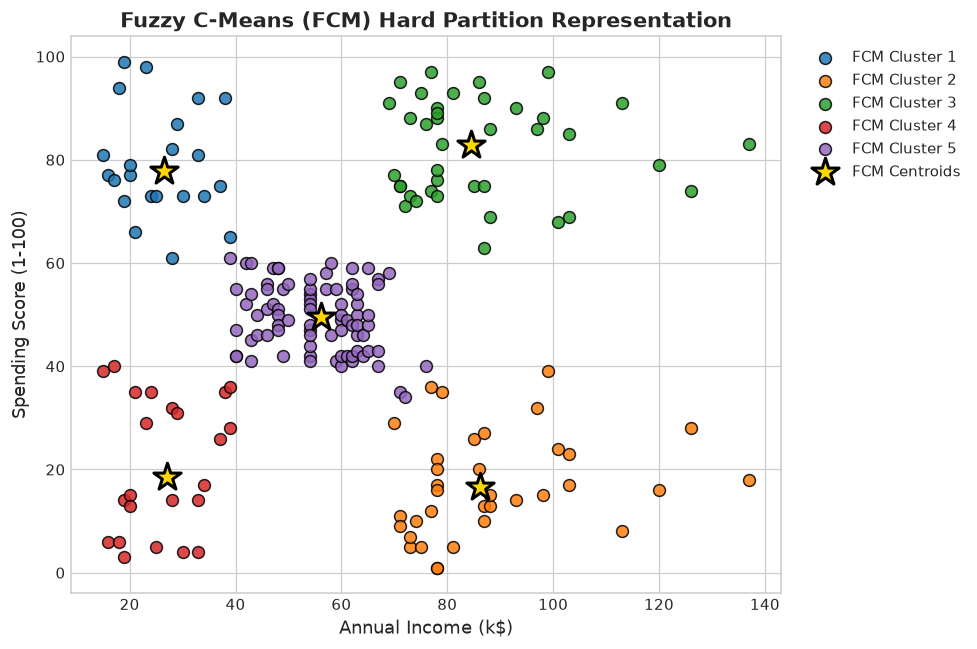

FCM Silhouette Score: 0.5547
FCM Davies-Bouldin Index: 0.5722


In [11]:
class FuzzyCMeans:
    """
    Fuzzy C-Means (FCM) clustering - implemented from scratch with NumPy.

    Each sample belongs to every cluster with a membership degree u_ik in [0, 1],
    and the memberships over the K clusters sum to 1 per sample.

    Parameters
    ----------
    n_clusters   : number of fuzzy clusters K
    m            : fuzzifier exponent (m > 1; larger m => fuzzier memberships)
    max_iter     : maximum number of alternating-optimization iterations
    tol          : convergence tolerance on the maximum membership change
    random_state : seed for reproducible random initialization
    """

    def __init__(self, n_clusters=5, m=2.0, max_iter=150, tol=1e-5, random_state=42):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        # Step 1: initialize the membership matrix U randomly and normalize every row to sum to 1
        U = rng.rand(n_samples, self.n_clusters)
        U = U / U.sum(axis=1, keepdims=True)

        # Step 2: alternate between centroid and membership updates until convergence
        for iteration in range(self.max_iter):
            U_old = U.copy()

            # 2a: centroid update - membership-weighted mean of the data
            Um = U ** self.m                                        # u_ik^m
            centers = np.dot(Um.T, X) / Um.sum(axis=0)[:, np.newaxis]

            # 2b: compute the (n_samples x n_clusters) distance matrix to every centroid
            dist = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
            dist = np.fmax(dist, 1e-10)  # avoid division by zero

            # 2c: membership update - closer points receive higher membership
            #     u_ik = 1 / sum_j (d_ik / d_ij)^(2/(m-1))
            inv_dist = 1.0 / dist
            power = 2.0 / (self.m - 1.0)
            inv_dist_p = inv_dist ** power
            U = inv_dist_p / inv_dist_p.sum(axis=1, keepdims=True)

            # 2d: stop when memberships stop changing (convergence)
            if np.max(np.abs(U - U_old)) < self.tol:
                break

        # Store results: final centroids, full membership matrix, and hard labels
        self.cluster_centers_ = centers
        self.u_ = U
        self.labels_ = np.argmax(U, axis=1)  # hard assignment = cluster with maximum membership
        return self


# Fit FCM with the same K as the other algorithms (m = 2 is the standard fuzzifier)
fcm = FuzzyCMeans(n_clusters=optimal_k, m=2.0, random_state=42)
fcm.fit(X_mall_scaled)
fcm_labels = fcm.labels_
fcm_centers = scaler.inverse_transform(fcm.cluster_centers_)

# ---- Visualize the hard partition derived from the soft memberships ----
plt.figure(figsize=(9, 6))
for cluster_id in range(optimal_k):
    cluster_points = X_mall[fcm_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'FCM Cluster {cluster_id + 1}', s=60, edgecolors='k', alpha=0.85)

plt.scatter(fcm_centers[:, 0], fcm_centers[:, 1], c='gold', marker='*', s=350, label='FCM Centroids', edgecolors='k', linewidths=2)
plt.title("Fuzzy C-Means (FCM) Hard Partition Representation", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Evaluation of the hard partition induced by the fuzzy memberships ----
print(f"FCM Silhouette Score: {silhouette_score(X_mall_scaled, fcm_labels):.4f}")
print(f"FCM Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, fcm_labels):.4f}")


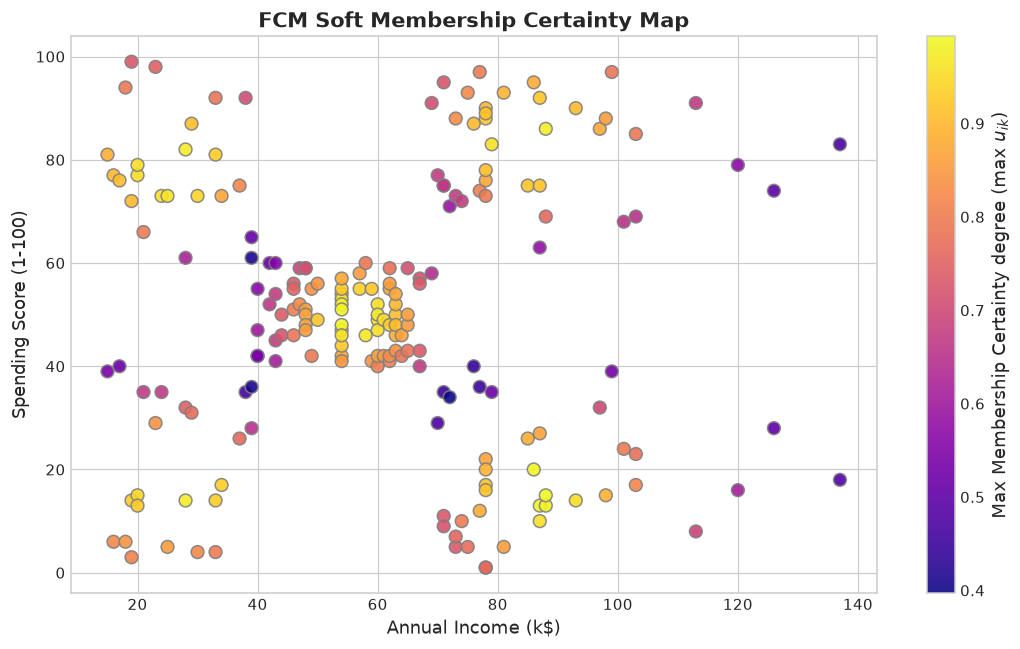

In [12]:
# ---- Visualizing the soft membership degrees (the key FCM output) ----
# For every customer take the maximum membership across clusters:
#   * close to 1.0  -> the point clearly belongs to one cluster
#   * near 1/K      -> the point is ambiguous (sits between clusters)
max_memberships = np.max(fcm.u_, axis=1)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_mall[:, 0], X_mall[:, 1], c=max_memberships, cmap='plasma', s=70, edgecolors='gray', alpha=0.9)
cbar = plt.colorbar(scatter)
cbar.set_label('Max Membership Certainty degree (max $u_{ik}$)', fontsize=12)
plt.title("FCM Soft Membership Certainty Map", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.tight_layout()
plt.show()


## 6. Comprehensive Quantitative Comparison
We evaluate all four clustering algorithms across three primary unsupervised metrics:
1. **Silhouette Score** (Higher is better: ranges from -1 to 1; measures intra-cluster cohesion vs. inter-cluster separation)
2. **Davies-Bouldin Index** (Lower is better: measures average similarity between clusters)
3. **Calinski-Harabasz Score** (Higher is better: ratio of between-clusters dispersion to within-cluster dispersion)


### Evaluation Process
1. Collect the final labels produced by each algorithm.
2. Compute Silhouette, Davies-Bouldin and Calinski-Harabasz on the standardized features.
3. Compare the results in a table (best values highlighted) and bar charts, then interpret differences.


In [13]:
# ---- Collect the labels produced by the four algorithms ----
models = {
    "Standard K-Means": kmeans_labels,
    "Bisecting K-Means": bisecting_labels,
    "Hierarchical (Ward)": agg_labels,
    "Fuzzy C-Means": fcm_labels
}

# ---- Compute the three unsupervised quality metrics for each partition ----
results = []
for name, labels in models.items():
    results.append({
        "Algorithm": name,
        "Silhouette Score": silhouette_score(X_mall_scaled, labels),                # higher is better
        "Davies-Bouldin Index": davies_bouldin_score(X_mall_scaled, labels),        # lower is better
        "Calinski-Harabasz Score": calinski_harabasz_score(X_mall_scaled, labels)   # higher is better
    })

df_comparison = pd.DataFrame(results).set_index("Algorithm")
print("Clustering Performance Comparison on Mall Customers:")
# Highlight the best value of each metric in green for quick comparison
display(df_comparison.style.highlight_max(subset=['Silhouette Score', 'Calinski-Harabasz Score'], color='lightgreen')
                           .highlight_min(subset=['Davies-Bouldin Index'], color='lightgreen'))


Clustering Performance Comparison on Mall Customers:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
Algorithm,,,
Standard K-Means,0.554657,0.572236,248.649320
Bisecting K-Means,0.480684,0.678789,150.938872
Hierarchical (Ward),0.553809,0.577862,244.410326
Fuzzy C-Means,0.554657,0.572236,248.649320


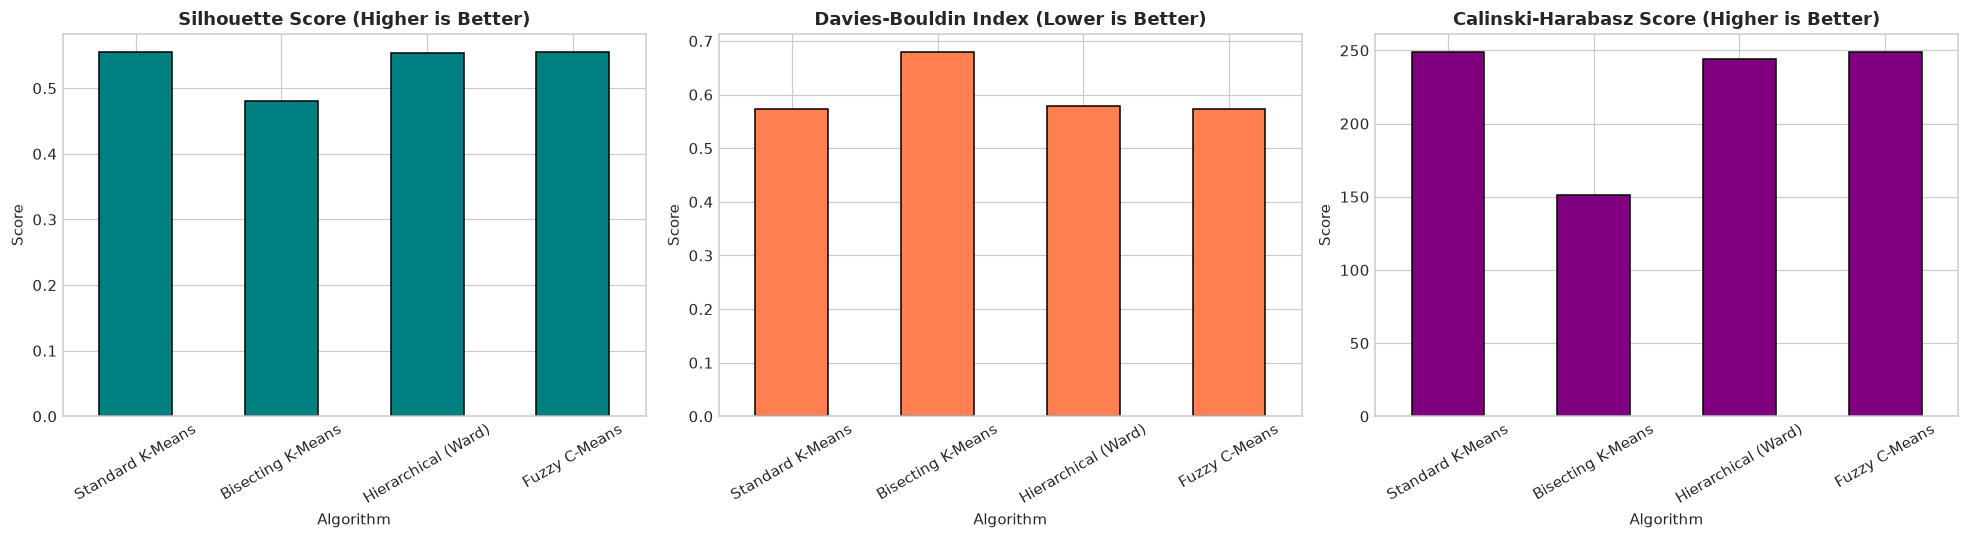

In [14]:
# ---- Bar-chart summary of the comparison table ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Silhouette Score (higher is better)
df_comparison['Silhouette Score'].plot(kind='bar', ax=axes[0], color='teal', edgecolor='k')
axes[0].set_title("Silhouette Score (Higher is Better)", fontweight='bold')
axes[0].set_ylabel("Score")
axes[0].tick_params(axis='x', rotation=30)

# Panel 2: Davies-Bouldin Index (lower is better)
df_comparison['Davies-Bouldin Index'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='k')
axes[1].set_title("Davies-Bouldin Index (Lower is Better)", fontweight='bold')
axes[1].set_ylabel("Score")
axes[1].tick_params(axis='x', rotation=30)

# Panel 3: Calinski-Harabasz Score (higher is better)
df_comparison['Calinski-Harabasz Score'].plot(kind='bar', ax=axes[2], color='purple', edgecolor='k')
axes[2].set_title("Calinski-Harabasz Score (Higher is Better)", fontweight='bold')
axes[2].set_ylabel("Score")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 7. Conclusions & Algorithm Selection Insights
- **Standard K-Means** provides an excellent balance of speed and cluster separation on globular, well-separated data.
- **Bisecting K-Means** prevents small outlier clusters from dominating the solution and yields stable, balanced partitions.
- **Hierarchical Clustering** requires no prior assumption about $K$ when constructing the tree, and the dendrogram offers visual interpretability into cluster hierarchy.
- **Fuzzy C-Means** captures overlapping clusters and data ambiguity, providing actionable membership probabilities for points along boundary regions.
